In [35]:
from generate_utils import load_GraphModel, load_BiLSTMModel
import torch
import numpy as np
import pickle
from tqdm import tqdm
from GridMLM_tokenizers import CSGridMLMTokenizer
from graph_utils import get_graph_embeddings_from_string_with_model, get_bilstm_embeddings_from_string_with_model, graph_from_string, compare_heterodata

In [36]:
tokenizer = CSGridMLMTokenizer(
    fixed_length=80,
    quantization='4th',
    intertwine_bar_info=True,
    trim_start=False,
    use_pc_roll=True,
    use_full_range_melody=False
)

In [37]:
device_name = 'cuda:0'
device = torch.device(device_name)

graph_model_path = 'saved_models/graph/graph_model.pt'
bilstm_model_path = 'saved_models/bilstm/bilstm_model.pt'

In [38]:
graph_model = load_GraphModel(graph_model_path, device)
bilstm_model = load_BiLSTMModel(bilstm_model_path, device)

In [39]:
graph_model.eval()
bilstm_model.eval()

HarmonyBiLSTM(
  (input_proj): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
  )
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (attn): Linear(in_features=256, out_features=1, bias=True)
  (output_proj): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
  )
)

In [40]:
datasets = {
    'gjt': {'path': 'data/gjt_test.pkl', 'dataset': None},
    # 'hook': {'path': 'data/hook_test.pkl', 'dataset': None},
    # 'nott': {'path': 'data/nott_test.pkl', 'dataset': None},
    # 'wiki': {'path': 'data/wiki_test.pkl', 'dataset': None}
}

In [41]:
for k, v in datasets.items():
    print(f'loading {k}')
    with open(v['path'], 'rb') as f:
        d = pickle.load(f)
    v['dataset'] = d

loading gjt


In [42]:
graph_embeddings = []
bilstm_embeddings = []
metadata = []

for k,v in datasets.items():
    for i, d in tqdm(enumerate(v['dataset'])):
        g = d['graph_ready_object']
        bar_objects = g.bar_objects
        for bar_start in range(len(bar_objects)-2):
            bar_end = bar_start + 2
            # graph
            g.make_graph_of_segment(bar_start, bar_end)
            z_graph = graph_model(g.segment_graph.to(device))
            graph_embeddings.append(
                z_graph.detach().cpu().numpy()
            )
            # bilstm
            g.make_bilstm_seq_of_segment(bar_start, bar_end)
            segment_bilstm = g.segment_bilstm.unsqueeze(0)
            lengths = torch.tensor(segment_bilstm.shape[1], dtype=int).unsqueeze(0)
            z_bilstm = bilstm_model(segment_bilstm.to(device), lengths.to(device))
            bilstm_embeddings.append(
                z_bilstm.detach().cpu().numpy()
            )
            # make string of chord symbols
            chords_str = f'{k}_{i}_[{bar_start}, {bar_end}]<br>'
            for bar_idx in range(bar_start, bar_end):
                chords_str += 'b_'
                for chord in bar_objects[bar_idx].chord_objects:
                    mel_pcs = [r.tolist() for pcs in chord.melody_pcs for r in pcs]
                    mel_pcs = list( set(mel_pcs) )
                    chords_str += tokenizer.ids_to_tokens[chord.chord_id] + '_@' + str(len(chord.bar_positions)) + \
                                    '_m' + repr(mel_pcs) + '<br>'
            metadata.append({
                'dataset': k,
                'piece_idx': i,
                'bar_start': bar_start,
                'bar_end': bar_end,
                'chords': chords_str
            })

graph_embeddings = np.vstack(graph_embeddings)
bilstm_embeddings = np.vstack(bilstm_embeddings)

28it [00:00, 32.94it/s]


In [43]:
print(graph_embeddings.shape)
print(bilstm_embeddings.shape)

(390, 128)
(390, 128)


In [44]:
print(metadata[100])

{'dataset': 'gjt', 'piece_idx': 7, 'bar_start': 8, 'bar_end': 10, 'chords': 'gjt_7_[8, 10]<br>b_F:maj7_@2_m[0, 9]<br>E:min7_@2_m[9, 11, 4, 7]<br>b_F:maj7_@2_m[9]<br>E:min7_@2_m[9]<br>'}


In [45]:
# in_seq_1 = 'b_C:maj_@0_m[0,4,9];A:7_@2_m[1,4]b_D:min_@0_m[2,5,7];G:7_@2_m[5,9,11]'
# in_seq_2 = 'b_C:maj_@0_m[0,4];A:7_@2_m[1,7]b_D:min_@0_m[2,5,9];G:7_@2_m[5,9,2]'
# in_seq_3 = 'b_A:7_@1_m[1,4];D:min_@0_m[2,5,7]b_G:7_@0m[5,9,11];C:maj_@2_m[0,4,9]'
# in_seq_4 = 'b_D:min_@0_m[2,5,7];G:7_@2_m[5,9,11]b_C:maj_@0_m[0,4,9];A:7_@2_m[1,4]'

in_seq_1 = 'b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]b_D:min_@4_m[2,5,7]'
in_seq_2 = 'b_C:maj_@2_m[0,4];A:7_@2_m[1,7]b_D:min_@4_m[2,5,9]'
in_seq_3 = 'b_A:7_@2_m[1,4];D:min_@2_m[2,5,7]b_G:7_@4m[5,9,11]'
# in_seq_4 = 'b_D:min_@0_m[2,5,7];G:7_@2_m[5,9,11]b_C:maj_@0_m[0,4,9]'

# in_seq_4 = 'b_E:min7_@2_m[2,7];D#:7_@2_m[7]b_G#:maj7_@2_m[7];G:7_@2_m[7]'
# in_seq_4 = 'b_E:min7_@2_m[2,7];D#:7_@2_m[7]b_G#:maj7_@2_m[7,1];G:7_@2_m[7]'
in_seq_4 = 'b_A:min_@2_m[7];D#:7_@2_m[7]b_G#:maj7_@2_m[7];G:7_@2_m[7]'

# in_seq_1 = 'b_G:7_@0;C:maj_@2'
# in_seq_2 = 'b_G:9_@0;C:maj_@2'
# in_seq_3 = 'b_B:hdim7_@0;C:maj_@2'
# in_seq_4 = 'b_C#:7_@0;C:maj_@2'

# in_seq_1 = 'b_C:7_@0;F:maj_@2'
# in_seq_2 = 'b_C:9_@0;F:maj_@2'
# in_seq_3 = 'b_E:hdim7_@0;F:maj_@2'
# in_seq_4 = 'b_F#:7_@0;F:maj_@2'

# in_seq_1 = 'b_D:7_@0;G:maj_@2'
# in_seq_2 = 'b_D:9_@0;G:maj_@2'
# in_seq_3 = 'b_F#:hdim7_@0;G:maj_@2'
# in_seq_4 = 'b_G#:7_@0;G:maj_@2'

# in_seq_1 = 'b_C:maj7_@0;F:maj_@2'
# in_seq_2 = 'b_C:maj9_@0;F:maj_@2'
# in_seq_3 = 'b_E:min7_@0;F:maj_@2'
# in_seq_4 = 'b_A:min7_@0;F:maj_@2'

# in_seq_1 = 'b_D:min7_@0;G:7_@2'
# in_seq_2 = 'b_D:min9_@0;G:7_@2'
# in_seq_3 = 'b_F:maj7_@0;G:7_@2'
# in_seq_4 = 'b_A:min7_@0;G:7_@2'

# in_seq_1 = 'b_E:min7_@0;A:7_@2'
# in_seq_2 = 'b_E:min9_@0;A:7_@2'
# in_seq_3 = 'b_G:maj7_@0;A:7_@2'
# in_seq_4 = 'b_B:min7_@0;A:7_@2'

# in_seq_1 = 'b_F#:min7_@0;B:7_@2'
# in_seq_2 = 'b_F#:min9_@0;B:7_@2'
# in_seq_3 = 'b_A:maj7_@0;B:7_@2'
# in_seq_4 = 'b_C#:min7_@0;B:7_@2'

# in_seq_1 = 'b_B:min7_@0;E:7_@2'
# in_seq_2 = 'b_B:min9_@0;E:7_@2'
# in_seq_3 = 'b_D:maj7_@0;E:7_@2'
# in_seq_4 = 'b_F#:min7_@0;E:7_@2'

# in_seq_1 = 'b_B:min7_@0b_E:7_@0'
# in_seq_2 = 'b_B:min9_@0b_E:7_@0'
# in_seq_3 = 'b_D:maj7_@0b_E:7_@0'
# in_seq_4 = 'b_F#:min7_@0b_E:7_@0'

y_graph_1 = get_graph_embeddings_from_string_with_model(in_seq_1, graph_model)
y_graph_2 = get_graph_embeddings_from_string_with_model(in_seq_2, graph_model)
y_graph_3 = get_graph_embeddings_from_string_with_model(in_seq_3, graph_model)
y_graph_4 = get_graph_embeddings_from_string_with_model(in_seq_4, graph_model)

y_bilstm_1 = get_bilstm_embeddings_from_string_with_model(in_seq_1, bilstm_model)
y_bilstm_2 = get_bilstm_embeddings_from_string_with_model(in_seq_2, bilstm_model)
y_bilstm_3 = get_bilstm_embeddings_from_string_with_model(in_seq_3, bilstm_model)
y_bilstm_4 = get_bilstm_embeddings_from_string_with_model(in_seq_4, bilstm_model)

C:maj in vocab as: 7
A:7 in vocab as: 274
D:min in vocab as: 66
C:maj in vocab as: 7
A:7 in vocab as: 274
D:min in vocab as: 66
A:7 in vocab as: 274
D:min in vocab as: 66
G:7 in vocab as: 216
A:min in vocab as: 269
D#:7 in vocab as: 100
G#:maj7 in vocab as: 246
G:7 in vocab as: 216
C:maj in vocab as: 7
A:7 in vocab as: 274
D:min in vocab as: 66
C:maj in vocab as: 7
A:7 in vocab as: 274
D:min in vocab as: 66
A:7 in vocab as: 274
D:min in vocab as: 66
G:7 in vocab as: 216
A:min in vocab as: 269
D#:7 in vocab as: 100
G#:maj7 in vocab as: 246
G:7 in vocab as: 216


In [46]:
from sklearn.decomposition import PCA

In [47]:
pca_graph = PCA(n_components=2)
pca_bilstm = PCA(n_components=2)

In [48]:
y_graph = pca_graph.fit_transform(graph_embeddings)
y_bilstm = pca_bilstm.fit_transform(bilstm_embeddings)

In [49]:
# transform new points
new_graph = np.vstack([
    y_graph_1.detach().cpu().numpy(),
    y_graph_2.detach().cpu().numpy(),
    y_graph_3.detach().cpu().numpy(),
    y_graph_4.detach().cpu().numpy(),
])

new_bilstm = np.vstack([
    y_bilstm_1.detach().cpu().numpy(),
    y_bilstm_2.detach().cpu().numpy(),
    y_bilstm_3.detach().cpu().numpy(),
    y_bilstm_4.detach().cpu().numpy(),
])

new_graph_2d = pca_graph.transform(new_graph)
new_bilstm_2d = pca_bilstm.transform(new_bilstm)

In [50]:
print(y_graph.shape, y_bilstm.shape)

(390, 2) (390, 2)


In [51]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

In [52]:
chords_list = [metadata[i]['chords'] for i in range(len(y_graph))]
df_graph = pd.DataFrame({
    'x': y_graph[:,0],
    'y': y_graph[:,1],
    'chords': chords_list
})
fig = px.scatter(data_frame=df_graph, x='x', y='y', hover_data=['chords'])
fig.add_trace(go.Scatter(
    x=new_graph_2d[:, 0],
    y=new_graph_2d[:, 1],
    mode='markers+text',
    marker=dict(color='red', size=10, symbol='x'),
    text=['y1', 'y2', 'y3', 'y4'],
    hovertext=[
        in_seq_1.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_2.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_3.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_4.replace(';','<br>').replace('b_', '<br>b_'),
    ],
    hoverinfo='text',
    textposition='top center',
    name='new graph points'
))
fig.show()

# fig = px.scatter(
#     data_frame=df,
#     x='x',
#     y='y',
#     hover_data=['chords']
# )
# fig.show()

In [53]:
chords_list = [metadata[i]['chords'] for i in range(len(y_graph))]
df_bilstm = pd.DataFrame({
    'x': y_bilstm[:,0],
    'y': y_bilstm[:,1],
    'chords': chords_list
})
fig = px.scatter(data_frame=df_bilstm, x='x', y='y', hover_data=['chords'])
fig.add_trace(go.Scatter(
    x=new_bilstm_2d[:, 0],
    y=new_bilstm_2d[:, 1],
    mode='markers+text',
    marker=dict(color='red', size=10, symbol='x'),
    text=['y1', 'y2', 'y3', 'y4'],
    hovertext=[
        in_seq_1.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_2.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_3.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_4.replace(';','<br>').replace('b_', '<br>b_'),
    ],
    hoverinfo='text',
    textposition='top center',
    name='new bilstm points'
))
fig.show()

# fig = px.scatter(
#     data_frame=df,
#     x='x',
#     y='y',
#     hover_data=['chords']
# )
# fig.show()

In [54]:
d = datasets['gjt']['dataset'][8]
d['graph_ready_object'].make_graph_of_segment(2,4)
d['graph_ready_object'].make_bilstm_seq_of_segment(2,4)

In [55]:
g = graph_from_string(in_seq_4)

A:min in vocab as: 269
D#:7 in vocab as: 100
G#:maj7 in vocab as: 246
G:7 in vocab as: 216


In [56]:
d['graph_ready_object'].print_info()
g.print_info()

Number of bars: 16
Segment bar range: [2, 4)
Segment graph features:
HeteroData(
  pitch={ x=[12, 12] },
  event={ x=[4, 1] },
  (pitch, participates, event)={
    edge_index=[2, 16],
    edge_attr=[16, 8],
  },
  (event, next, event)={
    edge_index=[2, 3],
    edge_attr=[3, 6],
  }
)
Segment graph bars:
Bar 3:
Bar token positions: [11, 12, 13, 14]
Number of chord objects in bar: 2
Chord object 1:
Chord label: E:min7
Pitch classes: [2, 4, 7, 11]
Root: 4
Chord ID: 131
Bar Positions: [0, 1]
Token Positions: [11, 12]
Melody PCs: [array([2, 7]), array([7])]
Graph Features:
tensor([[0., 0., 0., 1., 0., 1., 1., 0.],
        [1., 0., 0., 0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0., 1., 1., 0.],
        [0., 0., 1., 0., 0., 1., 0., 0.]])
BiLSTM Features
tensor([0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0.,
        0., 1., 0., 0., 0., 0.])
Chord object 2:
Chord label: D#:7
Pitch classes: [1, 3, 7, 10]
Root: 3
Chord ID: 100
Bar Positions: [2, 3]
Token Positions: 

In [57]:
graph_dataset = d['graph_ready_object'].segment_graph
graph_string = g.segment_graph

In [58]:
print(type(graph_dataset))
print(type(graph_string))

<class 'torch_geometric.data.hetero_data.HeteroData'>
<class 'torch_geometric.data.hetero_data.HeteroData'>


In [59]:
print(graph_dataset.node_types, graph_string.node_types)
print(graph_dataset.edge_types, graph_string.edge_types)

print(graph_dataset["event"].x.shape, graph_string["event"].x.shape)
print(graph_dataset["pitch","participates","event"].edge_index.shape,
      graph_string["pitch","participates","event"].edge_index.shape)

['pitch', 'event'] ['pitch', 'event']
[('pitch', 'participates', 'event'), ('event', 'next', 'event')] [('pitch', 'participates', 'event'), ('event', 'next', 'event')]
torch.Size([4, 1]) torch.Size([4, 1])
torch.Size([2, 16]) torch.Size([2, 16])


In [60]:
diffs = compare_heterodata(graph_dataset, graph_string)
print("differences:", diffs)

differences: ["('pitch', 'participates', 'event').edge_attr values differ", ' first diff edge_attr at [[0, 1], [0, 3], [0, 6], [1, 0], [1, 2]]', "('event', 'next', 'event').edge_attr values differ", ' first diff edge_attr at [[0, 3]]']


In [61]:
print(graph_dataset["event"].x)
print(graph_string["event"].x)

tensor([[0.],
        [2.],
        [0.],
        [2.]])
tensor([[0.],
        [2.],
        [0.],
        [2.]])


In [62]:
print(graph_dataset['event', 'next', 'event'].edge_attr)
print(graph_string['event', 'next', 'event'].edge_attr)

tensor([[0.0000, 0.0000, 0.1429, 1.0000, 1.0000, 0.0000],
        [1.0000, 0.0000, 0.3333, 1.0000, 0.0000, 1.0000],
        [0.0000, 1.0000, 0.1429, 0.0000, 1.0000, 0.0000]])
tensor([[0.0000, 0.0000, 0.1429, 0.0000, 1.0000, 0.0000],
        [1.0000, 0.0000, 0.3333, 1.0000, 0.0000, 1.0000],
        [0.0000, 1.0000, 0.1429, 0.0000, 1.0000, 0.0000]])


In [63]:
with torch.no_grad():
    test_graph_dataset = graph_model(d['graph_ready_object'].segment_graph)
with torch.no_grad():
    test_graph_string = graph_model(g.segment_graph)

In [64]:
with torch.no_grad():
    test_bilstm_dataset = bilstm_model(
        d['graph_ready_object'].segment_bilstm.unsqueeze(0).to(device),
        torch.tensor([d['graph_ready_object'].segment_bilstm.shape[0]]).to(device)
    )
with torch.no_grad():
    test_bilst_string = bilstm_model(
        g.segment_bilstm.unsqueeze(0).to(device),
        torch.tensor([g.segment_bilstm.shape[0]]).to(device)
    )

In [65]:
import matplotlib.pyplot as plt

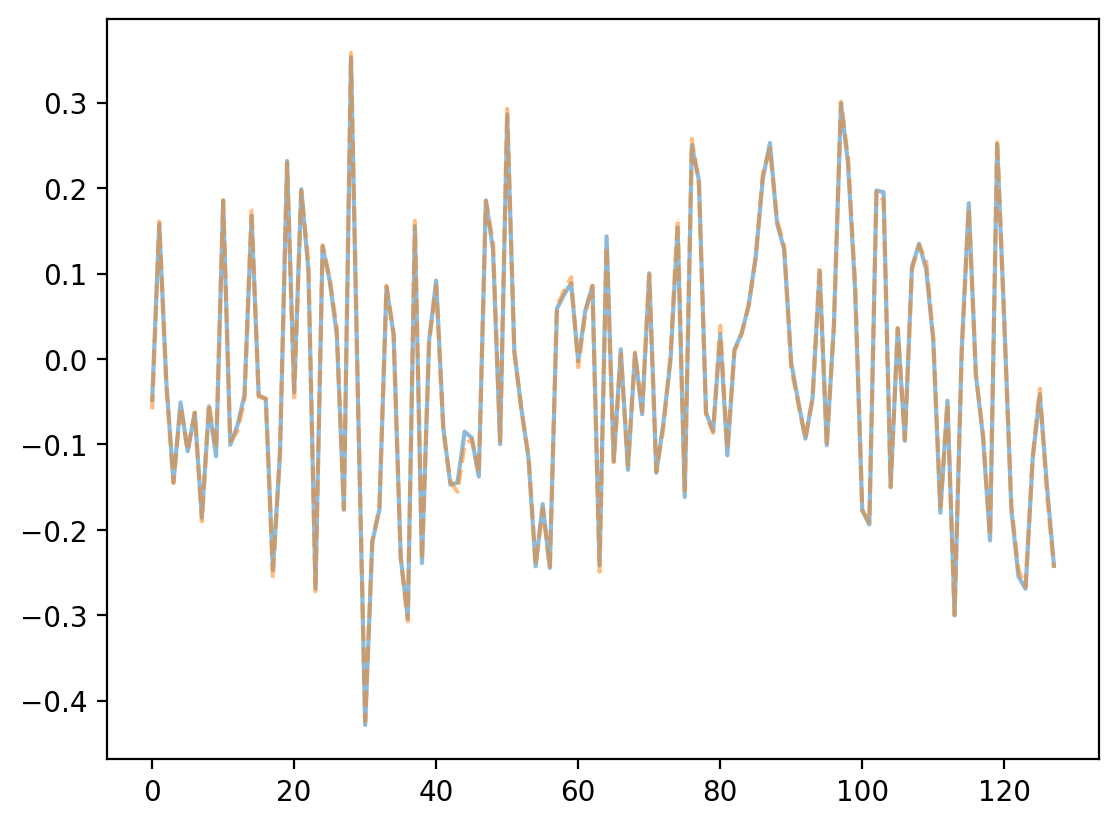

In [66]:
plt.plot(test_graph_dataset.detach().cpu().numpy(), alpha = 0.5)
plt.plot(test_graph_string.detach().cpu().numpy(), '--,', alpha = 0.5)

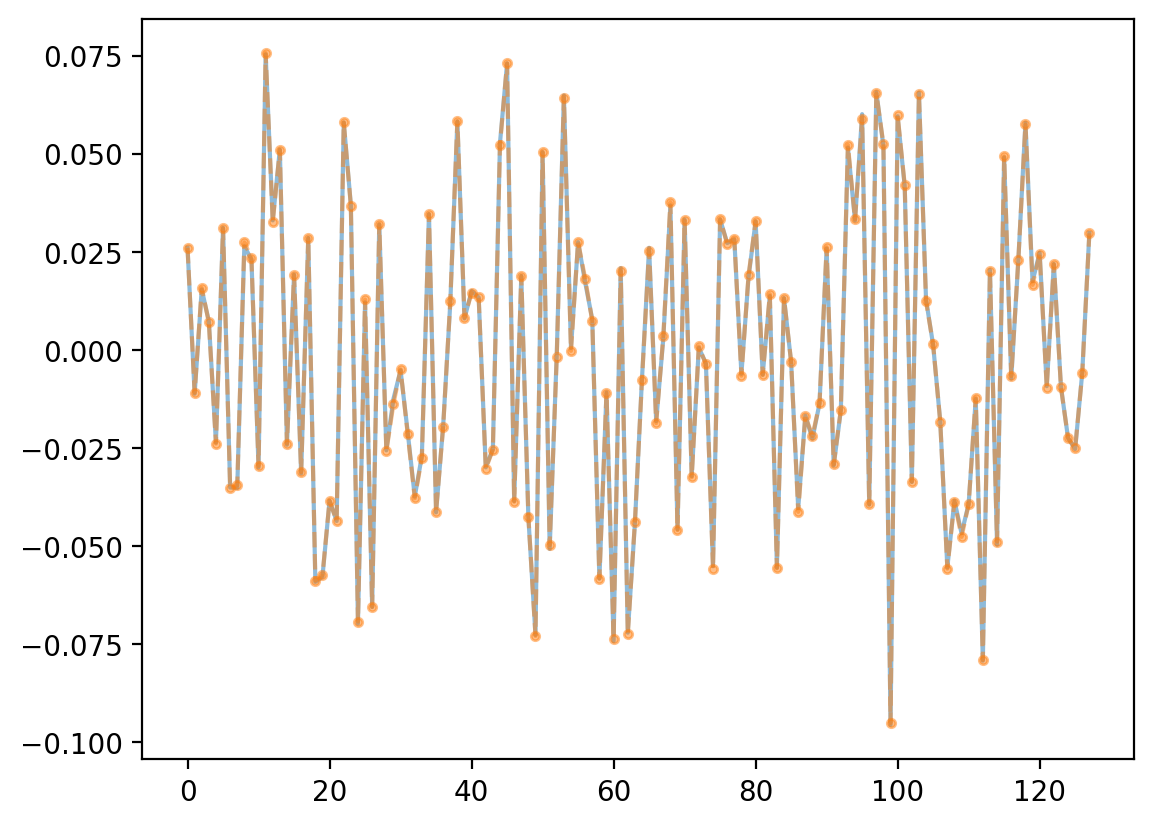

In [67]:
plt.plot(test_bilstm_dataset[0].detach().cpu().numpy(), alpha = 0.5)
plt.plot(test_bilst_string[0].detach().cpu().numpy(), '--.', alpha = 0.5)

In [68]:
print(g.segment_bilstm.shape)
print(d['graph_ready_object'].segment_bilstm.shape)

torch.Size([4, 24])
torch.Size([4, 24])
